In [17]:
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
)

chain = llm | StrOutputParser() 

In [19]:
from typing import TypedDict, Literal

class State(TypedDict):
    value: int
    decision: Literal["even", "odd"]  # 조건 판단 결과 저장

In [20]:
from langchain_core.messages import SystemMessage, HumanMessage

# 조건을 판단하고 판단 결과를 State에 저장하는 Node
def check_condition_node(state: State):
    print("check_condition_node 실행")
    print(f"value = {state['value']}")

    # --- LLM 호출 시작 ---
    system_prompt = (
        "당신은 업무흐름을 라우팅을 담당하는 어시스턴트입니다.\n"
        "숫자가 짝수면 'even', 홀수면 'odd' 만 정확히 출력하세요.\n"
        "추가 설명이나 다른 텍스트는 절대 출력하지 마세요."
    )
    user_prompt = f"숫자 {state['value']}는 짝수인가요, 홀수인가요? 'even' 또는 'odd'로만 답하세요."

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    # LLM 호출
    response = chain.invoke(messages)
    decision = response.strip().lower()

    print(f"LLM 응답: '{decision}'")

    # 유효성 검증
    if decision not in ["even", "odd"]:
        raise ValueError(f"LLM 응답이 예상과 다릅니다: {decision}")

    print(f"판단 결과를 State에 저장: decision = '{decision}'")
    print("=" * 40)
    # --- LLM 호출 완료 ---

    # 판단 결과를 State에 저장하여 반환
    return {"decision": decision}

# 짝수일 때 실행되는 Node
def even_node(state: State):
    print("even_node 실행: 짝수입니다!")
    print(f"value = {state['value']}")
    return state

# 홀수일 때 실행되는 Node
def odd_node(state: State):
    print("odd_node 실행: 홀수입니다!")
    print(f"value = {state['value']}")
    return state


In [21]:
def router(state: State) -> Literal["even", "odd"]:
    print("router 실행")
    print(f"State에 저장된 decision: {state['decision']}")

    # State에 이미 저장된 판단 결과를 단순히 반환만 함
    if state["decision"] == "even":
        print("짝수 Node로 이동")
        return "even"
    else:
        print("홀수 Node로 이동")
        return "odd"        

In [22]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("check_condition", check_condition_node)
graph_builder.add_node("even", even_node)
graph_builder.add_node("odd", odd_node)

graph_builder.add_edge(START, "check_condition")
graph_builder.add_conditional_edges(
    "check_condition",   
    router,         # router로 다음 Node 결정
    {
        "even": "even",
        "odd": "odd",
    }
)

graph_builder.add_edge("even", END)
graph_builder.add_edge("odd", END)

graph = graph_builder.compile()



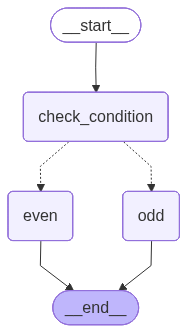

In [23]:
graph

In [24]:
# 짝수 입력하기
initial_message = {"value": 2}
result = graph.invoke(initial_message)
print("최종 결과:", result)

print('-' * 30)

### 홀수 입력하기
initial_message = {"value": 3}
result = graph.invoke(initial_message)
print("최종 결과:", result)


check_condition_node 실행
value = 2
LLM 응답: 'even'
판단 결과를 State에 저장: decision = 'even'
router 실행
State에 저장된 decision: even
짝수 Node로 이동
even_node 실행: 짝수입니다!
value = 2
최종 결과: {'value': 2, 'decision': 'even'}
------------------------------
check_condition_node 실행
value = 3
LLM 응답: 'odd'
판단 결과를 State에 저장: decision = 'odd'
router 실행
State에 저장된 decision: odd
홀수 Node로 이동
odd_node 실행: 홀수입니다!
value = 3
최종 결과: {'value': 3, 'decision': 'odd'}
